In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.interpolate import interp1d
from scipy.optimize import brentq

plt.rcParams.update({
    "font.size": 14,                 # 全局字号
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.direction": "in",         # 刻度朝内
    "ytick.direction": "in",
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.figsize": (5, 4),        # 图片默认大小
})

In [2]:
# ==========================================
# 1. 核心封装函数
# ==========================================

def get_nearest_val(k_x_target, k_y_target, kx_array, ky_array, data_matrix, error_matrix):
    """查找最近网格点的数值和误差"""
    idx_x = (np.abs(kx_array - k_x_target)).argmin()
    idx_y = (np.abs(ky_array - k_y_target)).argmin()
    val = data_matrix[idx_y, idx_x]
    err = error_matrix[idx_y, idx_x]
    return val, err

def extract_path_max(start_pt, end_pt, num_steps, kx_vals, ky_vals, Z, Zerr):
    """提取路径上的最大值及其对应的误差"""
    kxs = np.linspace(start_pt[0], end_pt[0], num_steps)
    kys = np.linspace(start_pt[1], end_pt[1], num_steps)
    
    vals = []
    errs = []
    for kx_t, ky_t in zip(kxs, kys):
        val, err = get_nearest_val(kx_t, ky_t, kx_vals, ky_vals, Z, Zerr)
        vals.append(val)
        errs.append(err)
    
    # 转为 numpy 数组方便处理
    vals = np.array(vals)
    errs = np.array(errs)
    
    # 找到最大值的索引
    idx_max = np.argmax(vals)
    return vals[idx_max], errs[idx_max]

def get_spectral_observables(data_dir, filename="spectra_ak0.csv"):
    """
    输入: data_dir (文件夹路径)
    输出: val_node, err_node, val_anti, err_anti, peak_val_MX, peak_err_MX, peak_val_XG, peak_err_XG
    """
    file_path = os.path.join(data_dir, filename)
    
    # 检查文件是否存在，防止报错中断循环
    if not os.path.exists(file_path):
        print(f"Warning: File not found {file_path}")
        return (np.nan,)*8 # 返回 8 个 NaN

    # 读取数据
    df = pd.read_csv(file_path)
    
    # 构造 Pivot Table
    pivot_val = df.pivot(index='ky', columns='kx', values='A_val')
    pivot_err = df.pivot(index='ky', columns='kx', values='Error') # 假设误差列名为 'Error'
    
    # 排序与提取坐标网格
    pivot_val.sort_index(ascending=True, inplace=True)
    pivot_val = pivot_val.reindex(sorted(pivot_val.columns), axis=1)
    # Error 表也要同步操作
    pivot_err.sort_index(ascending=True, inplace=True) 
    pivot_err = pivot_err.reindex(sorted(pivot_err.columns), axis=1)

    kx_vals = pivot_val.columns.values.astype(float)
    ky_vals = pivot_val.index.values.astype(float)
    Z_val = pivot_val.values
    Z_err = pivot_err.values
    
    # --- 1. 获取定点数据 (Node & Antinode) ---
    # Node: (pi/2, pi/2), Antinode: (pi, 0)
    target_node = (np.pi/2, np.pi/2)
    target_anti = (np.pi, 0)
    
    val_node, err_node = get_nearest_val(target_node[0], target_node[1], kx_vals, ky_vals, Z_val, Z_err)
    val_anti, err_anti = get_nearest_val(target_anti[0], target_anti[1], kx_vals, ky_vals, Z_val, Z_err)
    
    # --- 2. 获取路径峰值 ---
    # M(pi,0) -> X(pi,pi)
    pt_M = (np.pi, 0)
    pt_X = (np.pi, np.pi)
    pt_G = (0, 0)

    dx = np.mean(np.diff(kx_vals))
    dy = np.mean(np.diff(ky_vals))
    pt_X1 = (np.pi-dx, np.pi)
    pt_G1 = (0, 0+dy)
    pt_X2 = (np.pi, np.pi-dy)
    pt_G2 = (0+dx, 0)

    L = len(kx_vals)
    n_samples = int(L/2+1)
    
    # 采样点数根据网格密度大致估算，取50-100足够
    peak_val_MX, peak_err_MX = extract_path_max(pt_M, pt_X, n_samples, kx_vals, ky_vals, Z_val, Z_err)
    
    # X(pi,pi) -> Gamma(0,0)
    peak_val_XG0, peak_err_XG0 = extract_path_max(pt_X, pt_G, n_samples, kx_vals, ky_vals, Z_val, Z_err)
    peak_val_XG1, peak_err_XG1 = extract_path_max(pt_X1, pt_G1, n_samples-1, kx_vals, ky_vals, Z_val, Z_err)
    peak_val_XG2, peak_err_XG2 = extract_path_max(pt_X2, pt_G2, n_samples-1, kx_vals, ky_vals, Z_val, Z_err)
    candidates = [
        (peak_val_XG0, peak_err_XG0, "Central (Exact Diagonal)"),
        (peak_val_XG1, peak_err_XG1, "Offset 1 (Shift Up/Left)"),
        (peak_val_XG2, peak_err_XG2, "Offset 2 (Shift Down/Right)")
    ]
    best_candidate = max(candidates, key=lambda x: np.max(x[0]))
    peak_val_XG, peak_err_XG, chosen_label = best_candidate
    
    return val_node, err_node, val_anti, err_anti, peak_val_MX, peak_err_MX, peak_val_XG, peak_err_XG


In [3]:
# ==========================================
# 2. 主执行逻辑
# ==========================================

# 温度列表
T_list = [0.0001, 0.0005, 0.001, 0.005, 0.01, 
          0.015, 0.02, 0.025, 0.03, 0.04, 0.06]

# 结果容器
results = {
    "T": [],
    "val_node": [], "err_node": [],
    "val_anti": [], "err_anti": [],
    "peak_MX": [],  "err_MX": [],
    "peak_XG": [],  "err_XG": []
}

# 假设你的根目录在这里
base_dir = "./"  # 请修改为实际的数据根目录

print(f"Starting analysis for {len(T_list)} temperatures...")

for T in T_list:
    # 构造文件夹路径，例如 "T_0.001" 或 "T_0.001000" 取决于你的文件夹命名
    # 这里假设是简单的 T_0.001 格式。如果是浮点数格式化需要注意 (比如 {T:.3f})
    dir_name = f"T_{T}" 
    data_dir = os.path.join(base_dir, dir_name)
    
    print(f"Processing {dir_name}...", end="\r")
    
    # 调用函数
    v_n, e_n, v_a, e_a, p_mx, pe_mx, p_xg, pe_xg = get_spectral_observables(data_dir)
    
    # 存入列表
    results["T"].append(T)
    results["val_node"].append(v_n)
    results["err_node"].append(e_n)
    results["val_anti"].append(v_a)
    results["err_anti"].append(e_a)
    results["peak_MX"].append(p_mx)
    results["err_MX"].append(pe_mx)
    results["peak_XG"].append(p_xg)
    results["err_XG"].append(pe_xg)

print("\nAnalysis complete.")

# 转换为 numpy 数组方便绘图
for key in results:
    results[key] = np.array(results[key])

Starting analysis for 11 temperatures...
Processing T_0.06.....
Analysis complete.


In [4]:
df = pd.read_csv("summary_all.csv")
diff_func = interp1d(df['T'], df['Superfluid_Stiffness_mean'] - (2/np.pi)*df['T'], kind='linear')
Tc = brentq(diff_func, df['T'].min(), df['T'].max())

In [5]:
# fig, ax = plt.subplots(dpi=300)

# ax.errorbar(results["T"], results["val_anti"], yerr=results["err_anti"], 
#             fmt='-o', color='black')

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$A(\mathbf{k}=\mathbf{M}, \omega=0)$')
# ax.set_xlim(0,0.08) 
# # ax.set_ylim(0.58,0.76) 
# ax.legend(loc='best', frameon=False)
# plt.show()

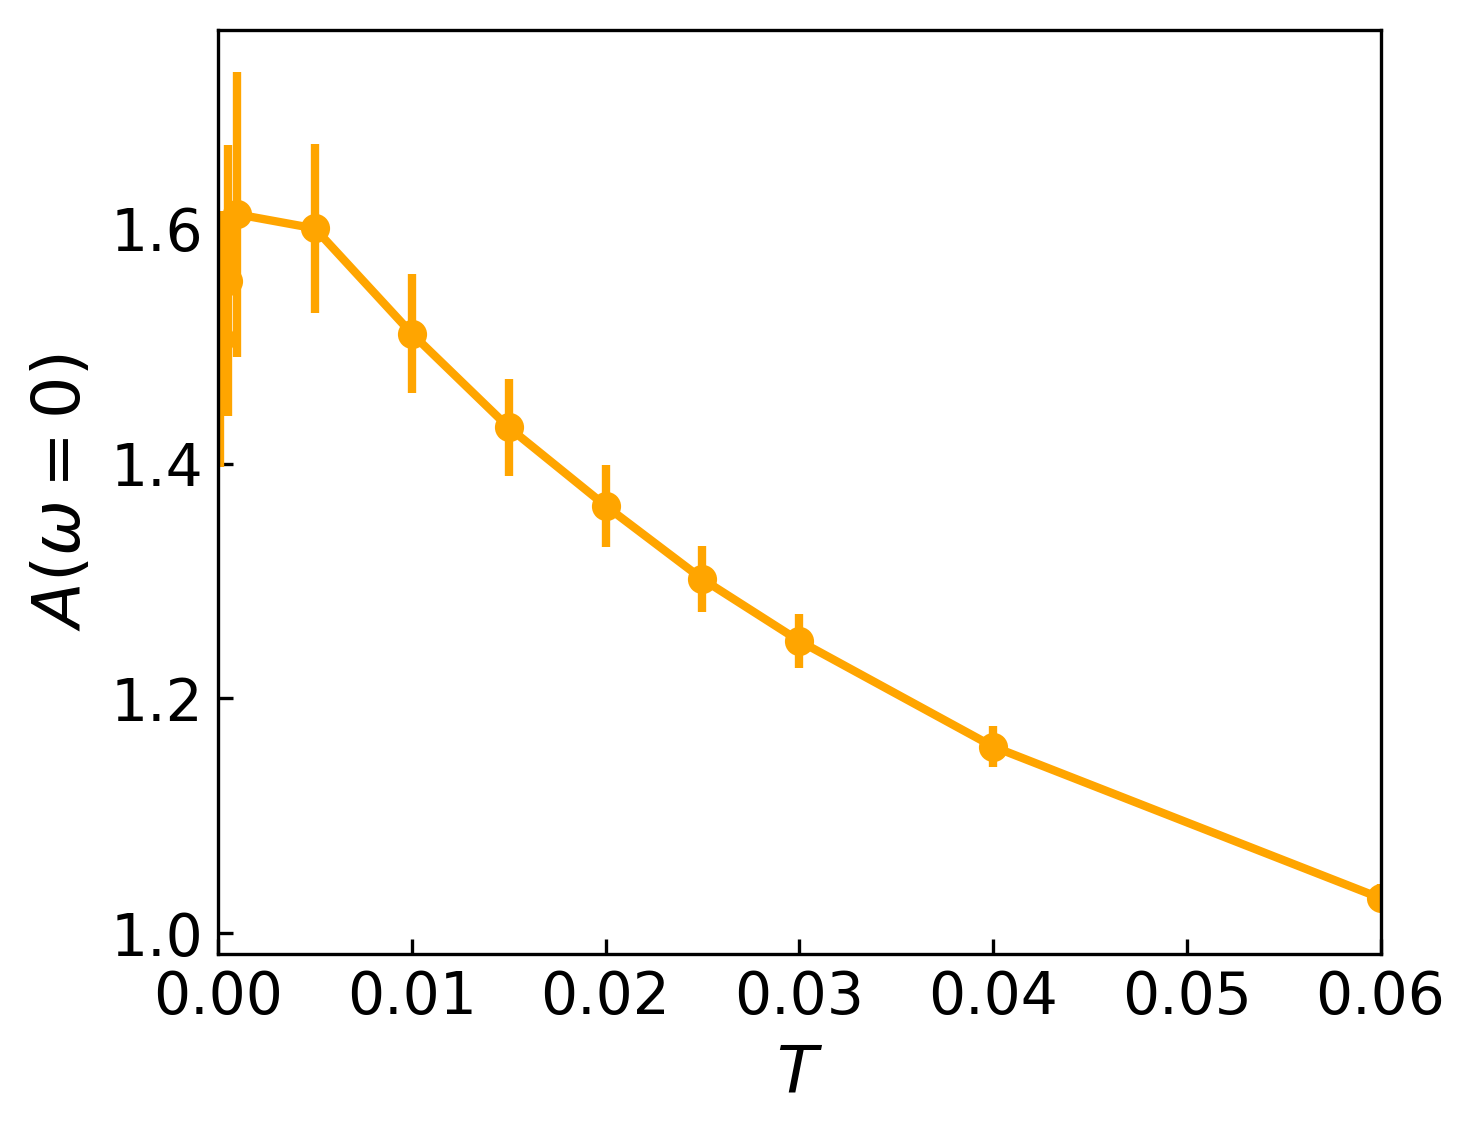

In [6]:
fig, ax = plt.subplots(dpi=300)

# ax.errorbar(results["T"], results["peak_XG"], yerr=results["err_XG"], 
#             fmt='-o', color='green', label=r'Nodal')
ax.errorbar(results["T"], results["peak_MX"], yerr=results["err_MX"], 
            fmt='-o', color='orange', label=r'Antinodal')

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# temp
# ax.axvline(x=0.02, color='black', linestyle='-', linewidth=1.5)

ax.set_xlabel(r'$T$')
# ax.set_ylabel('Peak Spectral Weight')
ax.set_ylabel(r'$A(\omega=0)$')
ax.set_xlim(0,0.06) 
# ax.set_ylim(1,1.76) 
# ax.legend(loc='best', frameon=False)
plt.show()

In [7]:
# fig, ax = plt.subplots(dpi=300)

# contrast = (results["peak_XG"] - results["peak_MX"]) / (results["peak_XG"] + results["peak_MX"])
# contrast_err = np.sqrt( (results["err_XG"]**2 + results["err_MX"]**2) ) / (results["peak_XG"] + results["peak_MX"])

# ax.errorbar(results["T"], contrast, yerr=contrast_err, 
#             fmt='-o', color='black')

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')
# ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

# ax.set_xlabel(r'$T$')
# ax.set_ylabel('Fermi surface contrast')
# ax.set_xlim(0,0.2) 
# # ax.set_ylim(-0.01,0.21) 
# ax.legend(loc='best', frameon=False)
# plt.show()